In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!git clone https://github.com/NMH1203/DL2026-13-18.git

Cloning into 'DL2026-13-18'...
remote: Enumerating objects: 24313, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 24313 (delta 2), reused 1 (delta 1), pack-reused 24301 (from 1)
Receiving objects: 100% (24313/24313), 826.09 MiB | 42.81 MiB/s, done.
Resolving deltas: 100% (212/212), done.
Updating files: 100% (31314/31314), done.


In [3]:
%cd /kaggle/working/DL2026-13-18

/kaggle/working/DL2026-13-18


In [4]:
!pwd
!ls

/kaggle/working/DL2026-13-18
app.py	 Doc	      references	review.md		templates
DATA.md  document.md  report		run.py			yolov8n.pt
Dataset  Notebooks    requirements.txt	sample_enhanced_images
demo.py  README.md    Results		src


In [5]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("GPU is NOT available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [9]:
import cv2
import yaml

print("OpenCV:", cv2.__version__)
print("PyYAML: OK")

try:
    from ultralytics import YOLO
    print("Ultralytics: OK")
except Exception as e:
    print("Ultralytics error:", e)

OpenCV: 4.14.0
PyYAML: OK
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: OK


In [7]:
!sed -n '1,240p' src/create_denoised_dataset.py

"""Build a YOLO dataset for: Zero-DCE/Zero-DCE++ -> Bilateral -> YOLOv8.

The filter changes pixel values only, so YOLO labels and the original
train/validation/test split are copied unchanged. Both common layouts are
supported: ``<split>/images`` and ``images/<split>``.
"""

from __future__ import annotations

import argparse
import json
import shutil
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import cv2
import yaml


EXTENSIONS = {".bmp", ".jpeg", ".jpg", ".png", ".webp"}
SPLITS = {"train": "train", "val": "valid", "test": "test"}


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Create a bilateral-filtered YOLO dataset")
    parser.add_argument("--source", required=True, type=Path)
    parser.add_argument("--output", required=True, type=Path)
    parser.add_argument("--diameter", type=int, default=5)
    parser.add_argument("--sigma-color", type=float, default=25.0)
    parser.add_argument("--sigma-space", ty

In [8]:
!pip install -q "ultralytics>=8.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 5.4 MB/s eta 0:00:00


In [10]:
from pathlib import Path

dataset_root = Path("/kaggle/working/DL2026-13-18/Dataset")

print("Dataset folder exists:", dataset_root.exists())

if dataset_root.exists():
    for p in dataset_root.iterdir():
        print(p)

Dataset folder exists: True
/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clean
/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_dark


In [11]:
!du -sh /kaggle/working/DL2026-13-18/Dataset

625M	/kaggle/working/DL2026-13-18/Dataset


In [12]:
!find /kaggle/working/DL2026-13-18/Dataset -type f | head -20

/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clean/valid/images/2015_06915_jpg.rf.77260147fe3dab453ebb60c263a22d46.jpg
/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clean/valid/images/2015_02362_jpg.rf.7c88abe3609193974386274750bcb392.jpg
/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clean/valid/images/2015_04426_jpg.rf.ad23c54d553805b8bc1760829ad725c8.jpg
/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clean/valid/images/2015_01984_jpg.rf.aa93154c779500ef1174265c014c7a7e.jpg
/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clean/valid/images/2015_02547_jpg.rf.add2de5ee367c8848f78f873aab77c34.jpg
/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clean/valid/images/2015_02792_jpg.rf.31e3483d2afcb9c3676c3c0e8013f81c.jpg
/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clean/valid/images/2015_01307_jpg.rf.498eb3870bb5c14bcbe3d994162f35ab.jpg
/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clean/valid/images/2015_05262_jpg.rf.e9fecfed930c99fad78e1ca2090e85c6.jpg
/kaggle/working/

In [13]:
from pathlib import Path
import yaml

DATASET = Path("/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_dark")

print("Dataset exists:", DATASET.exists())
print("Dataset path:", DATASET)

print("\n--- Split counts ---")

for split in ["train", "valid", "test"]:
    image_dir = DATASET / split / "images"
    label_dir = DATASET / split / "labels"

    image_count = len(list(image_dir.glob("*")))
    label_count = len(list(label_dir.glob("*.txt")))

    print(f"{split:5s}: images={image_count}, labels={label_count}")

print("\n--- Classes ---")

with open(DATASET / "data.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print(config["names"])

Dataset exists: True
Dataset path: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_dark

--- Split counts ---
train: images=5142, labels=5142
valid: images=1469, labels=1469
test : images=734, labels=734

--- Classes ---
{0: 'Bicycle', 1: 'Boat', 2: 'Bottle', 3: 'Bus', 4: 'Cat', 5: 'Cup', 6: 'Motorbike', 7: 'People', 8: 'Table', 9: 'car', 10: 'chair', 11: 'dog'}


In [14]:
from pathlib import Path

# Original ExDark YOLO dataset
SOURCE_DATASET = Path(
    "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_dark"
)

# New CLAHE-only dataset
OUTPUT_DATASET = Path(
    "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_new"
)

SPLITS = ["train", "valid", "test"]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff",
}

print("Source dataset :", SOURCE_DATASET)
print("Output dataset :", OUTPUT_DATASET)

print("\nSource exists:", SOURCE_DATASET.exists())

for split in SPLITS:
    image_dir = SOURCE_DATASET / split / "images"
    label_dir = SOURCE_DATASET / split / "labels"

    print(
        f"{split}: "
        f"images={image_dir.exists()}, "
        f"labels={label_dir.exists()}"
    )

Source dataset : /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_dark
Output dataset : /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_new

Source exists: True
train: images=True, labels=True
valid: images=True, labels=True
test: images=True, labels=True


In [15]:
import cv2
import numpy as np


def enhance_clahe(image_bgr: np.ndarray) -> np.ndarray:
    if image_bgr is None or image_bgr.size == 0:
        raise ValueError("Input image is empty.")

    # Convert BGR to CIE LAB
    lab = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2LAB,
    )

    # Split L, A, B channels
    luminance, channel_a, channel_b = cv2.split(lab)

    # Apply CLAHE only to luminance
    luminance = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8),
    ).apply(luminance)

    # Merge channels and convert back to BGR
    enhanced = cv2.cvtColor(
        cv2.merge(
            (
                luminance,
                channel_a,
                channel_b,
            )
        ),
        cv2.COLOR_LAB2BGR,
    )

    return enhanced

In [16]:
import matplotlib.pyplot as plt

sample_image = next(
    p for p in (SOURCE_DATASET / "train" / "images").iterdir()
    if p.suffix.lower() in IMAGE_EXTENSIONS
)

image_bgr = cv2.imread(
    str(sample_image),
    cv2.IMREAD_COLOR,
)

enhanced_bgr = enhance_clahe(image_bgr)

print("Sample:", sample_image.name)
print("Original shape :", image_bgr.shape)
print("Enhanced shape :", enhanced_bgr.shape)

Sample: 2015_02552_jpg.rf.7b643522a29c9298946f0a05fd76b094.jpg
Original shape : (640, 640, 3)
Enhanced shape : (640, 640, 3)


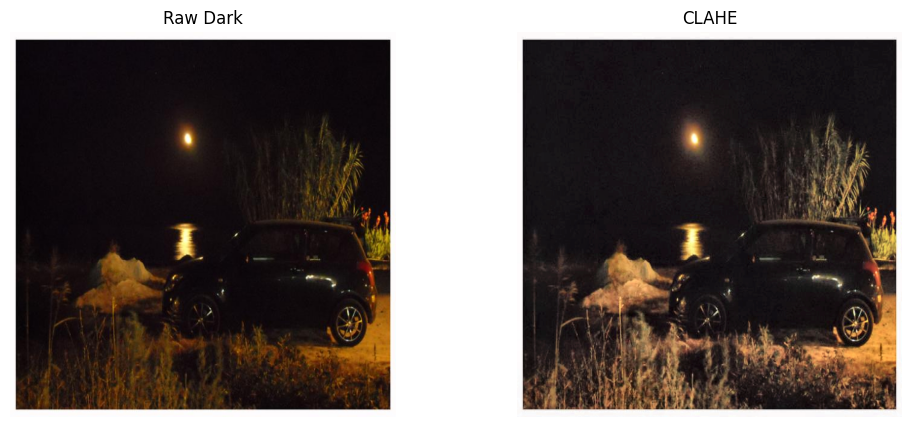

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
plt.title("Raw Dark")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2RGB))
plt.title("CLAHE")
plt.axis("off")

plt.show()

In [18]:
import cv2
import shutil
from tqdm.auto import tqdm

# Make sure output directory is new
OUTPUT_DATASET.mkdir(parents=True, exist_ok=True)

total_processed = 0
total_skipped = 0

for split in SPLITS:
    source_images_dir = SOURCE_DATASET / split / "images"
    source_labels_dir = SOURCE_DATASET / split / "labels"

    output_images_dir = OUTPUT_DATASET / split / "images"
    output_labels_dir = OUTPUT_DATASET / split / "labels"

    output_images_dir.mkdir(parents=True, exist_ok=True)
    output_labels_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(
        path
        for path in source_images_dir.iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    label_paths = sorted(source_labels_dir.glob("*.txt"))

    print(
        f"\n{split}: "
        f"{len(image_paths)} images, "
        f"{len(label_paths)} labels"
    )

    # Copy labels unchanged
    for label_path in label_paths:
        destination = output_labels_dir / label_path.name

        if not destination.exists():
            shutil.copy2(label_path, destination)

    # Apply CLAHE to every image
    for image_path in tqdm(
        image_paths,
        desc=f"CLAHE {split}",
    ):
        output_path = (
            output_images_dir
            / f"{image_path.stem}.png"
        )

        # Skip already processed images
        if output_path.exists() and output_path.stat().st_size > 0:
            total_skipped += 1
            continue

        image_bgr = cv2.imread(
            str(image_path),
            cv2.IMREAD_COLOR,
        )

        if image_bgr is None:
            raise ValueError(
                f"Cannot read image: {image_path}"
            )

        original_shape = image_bgr.shape

        enhanced_bgr = enhance_clahe(image_bgr)

        # CLAHE must not change image geometry
        if enhanced_bgr.shape != original_shape:
            raise ValueError(
                f"Image shape changed: {image_path}"
            )

        success = cv2.imwrite(
            str(output_path),
            enhanced_bgr,
            [cv2.IMWRITE_PNG_COMPRESSION, 3],
        )

        if not success:
            raise IOError(
                f"Cannot save image: {output_path}"
            )

        total_processed += 1

print("\n===================================")
print("CLAHE DATASET GENERATION COMPLETED")
print("===================================")
print("New images processed :", total_processed)
print("Existing skipped     :", total_skipped)


train: 5142 images, 5142 labels


CLAHE train:   0%|          | 0/5142 [00:00<?, ?it/s]


valid: 1469 images, 1469 labels


CLAHE valid:   0%|          | 0/1469 [00:00<?, ?it/s]


test: 734 images, 734 labels


CLAHE test:   0%|          | 0/734 [00:00<?, ?it/s]


CLAHE DATASET GENERATION COMPLETED
New images processed : 7345
Existing skipped     : 0


In [19]:
import yaml

SOURCE_YAML = SOURCE_DATASET / "data.yaml"
OUTPUT_YAML = OUTPUT_DATASET / "data.yaml"

with open(SOURCE_YAML, "r", encoding="utf-8") as f:
    source_config = yaml.safe_load(f)

output_config = {
    "path": str(OUTPUT_DATASET),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": source_config["names"],
}

with open(OUTPUT_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        output_config,
        f,
        sort_keys=False,
        allow_unicode=True,
    )

print("Created:", OUTPUT_YAML)
print()
print(yaml.dump(output_config, sort_keys=False))

Created: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_new/data.yaml

path: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_new
train: train/images
val: valid/images
test: test/images
names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Cat
  5: Cup
  6: Motorbike
  7: People
  8: Table
  9: car
  10: chair
  11: dog



In [20]:
print("========== CLAHE DATASET CHECK ==========")

all_ok = True

expected_counts = {
    "train": 5142,
    "valid": 1469,
    "test": 734,
}

for split in SPLITS:
    image_dir = OUTPUT_DATASET / split / "images"
    label_dir = OUTPUT_DATASET / split / "labels"

    images = [
        p for p in image_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    labels = [
        p for p in label_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() == ".txt"
    ]

    expected = expected_counts[split]

    print(f"\n{split.upper()}")
    print("Images :", len(images))
    print("Labels :", len(labels))
    print("Expected:", expected)

    if len(images) != expected or len(labels) != expected:
        all_ok = False

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    print("Missing labels:", len(missing_labels))
    print("Missing images:", len(missing_images))

    if missing_labels or missing_images:
        all_ok = False

print("\n===================================")

if all_ok:
    print("✅ CLAHE DATASET IS READY")
else:
    print("❌ CLAHE DATASET HAS PROBLEMS")

========== CLAHE DATASET CHECK ==========

TRAIN
Images : 5142
Labels : 5142
Expected: 5142
Missing labels: 0
Missing images: 0

VALID
Images : 1469
Labels : 1469
Expected: 1469
Missing labels: 0
Missing images: 0

TEST
Images : 734
Labels : 734
Expected: 734
Missing labels: 0
Missing images: 0

✅ CLAHE DATASET IS READY


Raw   : (640, 640, 3)
CLAHE : (640, 640, 3)


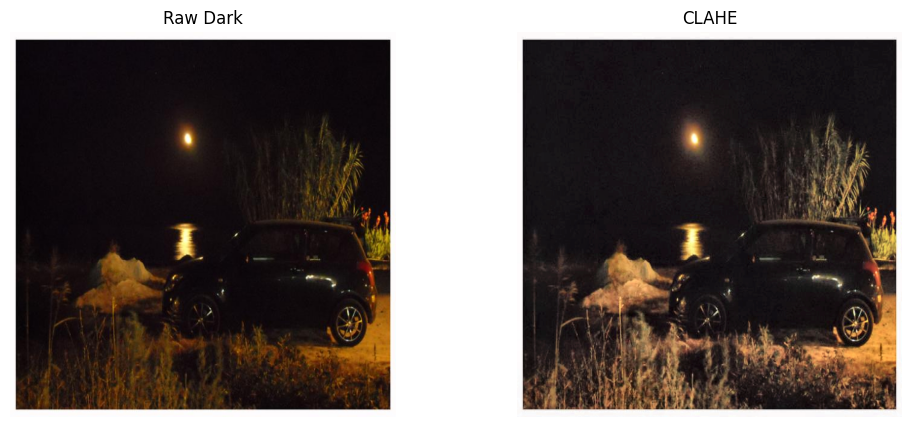

In [21]:
import matplotlib.pyplot as plt

raw_image = next(
    p for p in (SOURCE_DATASET / "train" / "images").iterdir()
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
)

clahe_image = (
    OUTPUT_DATASET
    / "train"
    / "images"
    / f"{raw_image.stem}.png"
)

raw = cv2.imread(str(raw_image))
clahe = cv2.imread(str(clahe_image))

print("Raw   :", raw.shape)
print("CLAHE :", clahe.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
plt.title("Raw Dark")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(clahe, cv2.COLOR_BGR2RGB))
plt.title("CLAHE")
plt.axis("off")

plt.show()

In [37]:
from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working/DL2026-13-18")

DENOISE_SCRIPT = PROJECT_ROOT / "src" / "create_denoised_dataset.py"

print("Script exists:", DENOISE_SCRIPT.exists())
print("Script:", DENOISE_SCRIPT)

Script exists: True
Script: /kaggle/working/DL2026-13-18/src/create_denoised_dataset.py


In [23]:
from pathlib import Path

CLAHE_DATASET = (
    PROJECT_ROOT
    / "Dataset"
    / "exdark_yolo_clahe_new"
)

SMOKE_DATASET = (
    PROJECT_ROOT
    / "Dataset"
    / "exdark_yolo_clahe_denoised_smoke"
)

print("Source:", CLAHE_DATASET)
print("Smoke output:", SMOKE_DATASET)

Source: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_new
Smoke output: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_smoke


In [31]:
import shutil
from pathlib import Path

SMOKE_DATASET = Path(
    "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_smoke"
)

if SMOKE_DATASET.exists():
    shutil.rmtree(SMOKE_DATASET)
    print("Old smoke-test dataset deleted.")
else:
    print("Smoke-test dataset does not exist.")

Smoke-test dataset does not exist.


In [32]:
!python src/create_denoised_dataset.py \
    --source "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_new" \
    --output "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_smoke" \
    --diameter 5 \
    --sigma-color 25 \
    --sigma-space 25 \
    --workers 4 \
    --limit 20

Completed train: 20 pairs
Completed val: 20 pairs
Completed test: 20 pairs
Ready: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_smoke/data.yaml


In [35]:
import json
from pathlib import Path

SMOKE_DATASET = Path(
    "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_smoke"
)

metadata_path = SMOKE_DATASET / "denoising_metadata.json"

print("Metadata exists:", metadata_path.exists())

if metadata_path.exists():
    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    print(json.dumps(metadata, indent=2))

Metadata exists: True
{
  "source": "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_new",
  "method": "OpenCV bilateralFilter",
  "diameter": 5,
  "sigma_color": 25.0,
  "sigma_space": 25.0,
  "counts": {
    "train": 20,
    "val": 20,
    "test": 20
  },
  "smoke_test_limit": 20
}


In [36]:
import shutil

shutil.rmtree(
    "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_smoke"
)

print("Smoke-test dataset removed.")

Smoke-test dataset removed.


In [38]:
!python src/create_denoised_dataset.py \
    --source "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_new" \
    --output "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new" \
    --diameter 5 \
    --sigma-color 25 \
    --sigma-space 25 \
    --workers 4

Completed train: 5142 pairs
Completed val: 1469 pairs
Completed test: 734 pairs
Ready: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new/data.yaml


In [39]:
from pathlib import Path

DENOISED_DATASET = Path(
    "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new"
)

expected = {
    "train": 5142,
    "valid": 1469,
    "test": 734,
}

all_ok = True

for split, expected_count in expected.items():
    image_dir = DENOISED_DATASET / split / "images"
    label_dir = DENOISED_DATASET / split / "labels"

    images = list(image_dir.glob("*"))
    labels = list(label_dir.glob("*.txt"))

    print(
        f"{split}: "
        f"images={len(images)}, "
        f"labels={len(labels)}, "
        f"expected={expected_count}"
    )

    if len(images) != expected_count or len(labels) != expected_count:
        all_ok = False

print("\nResult:", "✅ DATASET READY" if all_ok else "❌ CHECK DATASET")

train: images=5142, labels=5142, expected=5142
valid: images=1469, labels=1469, expected=1469
test: images=734, labels=734, expected=734

Result: ✅ DATASET READY


In [40]:
import json

metadata_path = DENOISED_DATASET / "denoising_metadata.json"

with open(metadata_path, "r") as f:
    metadata = json.load(f)

print(json.dumps(metadata, indent=2))

{
  "source": "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_new",
  "method": "OpenCV bilateralFilter",
  "diameter": 5,
  "sigma_color": 25.0,
  "sigma_space": 25.0,
  "counts": {
    "train": 5142,
    "val": 1469,
    "test": 734
  },
  "smoke_test_limit": null
}


In [41]:
from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working/DL2026-13-18")

DENOISED_DATASET = (
    PROJECT_ROOT
    / "Dataset"
    / "exdark_yolo_clahe_denoised_new"
)

DATA_YAML = DENOISED_DATASET / "data.yaml"

TRAIN_SCRIPT = (
    PROJECT_ROOT
    / "src"
    / "LBN"
    / "train_ninh.py"
)

MODEL_PATH = PROJECT_ROOT / "yolov8n.pt"

RESULTS_ROOT = (
    PROJECT_ROOT
    / "Results"
    / "NDN"
)

RUN_NAME = "yolov8n_clahe_denoised_new_e40"

RESULT_DIR = RESULTS_ROOT / RUN_NAME

print("Dataset:", DENOISED_DATASET)
print("data.yaml exists:", DATA_YAML.exists())
print("Training script exists:", TRAIN_SCRIPT.exists())
print("YOLOv8n exists:", MODEL_PATH.exists())
print("Result directory:", RESULT_DIR)

Dataset: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new
data.yaml exists: True
Training script exists: True
YOLOv8n exists: True
Result directory: /kaggle/working/DL2026-13-18/Results/NDN/yolov8n_clahe_denoised_new_e40


In [42]:
import yaml

with open(DATA_YAML, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print(yaml.dump(config, sort_keys=False))

path: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new
train: train/images
val: valid/images
test: test/images
names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Cat
  5: Cup
  6: Motorbike
  7: People
  8: Table
  9: car
  10: chair
  11: dog



In [43]:
print("Result directory exists:", RESULT_DIR.exists())

Result directory exists: False


In [44]:
!python src/LBN/train_ninh.py train \
    --data "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new/data.yaml" \
    --device 0 \
    --project "/kaggle/working/DL2026-13-18/Results/NDN" \
    --name "yolov8n_clahe_denoised_new_e40" \
    --epochs 40 \
    --batch 16 \
    --imgsz 640 \
    --seed 42 \
    --patience 15

Device=0, CUDA available=True
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, mul

In [48]:
from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working/DL2026-13-18")

DENOISED_DATASET = (
    PROJECT_ROOT
    / "Dataset"
    / "exdark_yolo_clahe_denoised_new"
)

DATA_YAML = DENOISED_DATASET / "data.yaml"

TRAIN_RUN = (
    PROJECT_ROOT
    / "Results"
    / "NDN"
    / "yolov8n_clahe_denoised_new_e40"
)

BEST_PT = TRAIN_RUN / "weights" / "best.pt"

print("Dataset:", DENOISED_DATASET)
print("data.yaml:", DATA_YAML.exists())
print("best.pt:", BEST_PT.exists())
print("best.pt path:", BEST_PT)

Dataset: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new
data.yaml: True
best.pt: True
best.pt path: /kaggle/working/DL2026-13-18/Results/NDN/yolov8n_clahe_denoised_new_e40/weights/best.pt


In [49]:
test_images = list(
    (DENOISED_DATASET / "test" / "images").glob("*")
)

test_labels = list(
    (DENOISED_DATASET / "test" / "labels").glob("*.txt")
)

print("Test images :", len(test_images))
print("Test labels :", len(test_labels))

Test images : 734
Test labels : 734


In [50]:
!python src/LBN/train_ninh.py evaluate \
    --data "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new/data.yaml" \
    --weights "/kaggle/working/DL2026-13-18/Results/NDN/yolov8n_clahe_denoised_new_e40/weights/best.pt" \
    --split test \
    --device 0 \
    --project "/kaggle/working/DL2026-13-18/Results/NDN" \
    --name "yolov8n_clahe_denoised_new_e40_test" \
    --batch 16 \
    --imgsz 640

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3456.4±350.0 MB/s, size: 327.6 KB)
val: Scanning /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new/test/labels... 734 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 734/734 312.6it/s 2.3s0.1s
val: New cache created: /kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 2.8it/s 16.7s0.3s
                   all        734       2248      0.681      0.579      0.624      0.293
               Bicycle         70        116       0.76      0.638        0.7      0.286
                  Boat         64        159      0.681      0.528      0.611      0.237
                Bottle         64        135      0.628      0

In [51]:
from pathlib import Path

TEST_RUN = Path(
    "/kaggle/working/DL2026-13-18/Results/NDN/yolov8n_clahe_denoised_new_e40_test"
)

print("========== TEST RESULTS ==========")

for p in [
    TEST_RUN / "measured_metrics.json",
    TEST_RUN / "measured_metrics.csv",
]:
    print(f"{p.name:25}:", p.exists())
    

========== TEST RESULTS ==========
measured_metrics.json    : True
measured_metrics.csv     : True


In [52]:
import json

metrics_file = TEST_RUN / "measured_metrics.json"

with open(metrics_file, "r") as f:
    metrics = json.load(f)

print(json.dumps(metrics, indent=2))

{
  "weights": "/kaggle/working/DL2026-13-18/Results/NDN/yolov8n_clahe_denoised_new_e40/weights/best.pt",
  "data": "/kaggle/working/DL2026-13-18/Dataset/exdark_yolo_clahe_denoised_new/data.yaml",
  "split": "test",
  "precision": 0.6810812771287925,
  "recall": 0.5793009307844815,
  "map50": 0.6240195933366824,
  "map50_95": 0.2933597030139571
}
